#  Wafer fault Prediction

**Brief:** In electronics, a **wafer** (also called a slice or substrate) is a thin slice of semiconductor, such as a crystalline silicon (c-Si), used for the fabrication of integrated circuits and, in photovoltaics, to manufacture solar cells. The wafer serves as the substrate(serves as foundation for contruction of other components) for microelectronic devices built in and upon the wafer. 

It undergoes many microfabrication processes, such as doping, ion implantation, etching, thin-film deposition of various materials, and photolithographic patterning. Finally, the individual microcircuits are separated by wafer dicing and packaged as an integrated circuit.

## Problem Statement

**Data:** Wafers data


**Problem Statement:** Wafers are predominantly used to manufacture solar cells and are located at remote locations in bulk and they themselves consist of few hundreds of sensors. Wafers are fundamental of photovoltaic power generation, and production thereof requires high technology. Photovoltaic power generation system converts sunlight energy directly to electrical energy.

The motto behind figuring out the faulty wafers is to obliterate the need of having manual man-power doing the same. And make no mistake when we're saying this, even when they suspect a certain wafer to be faulty, they had to open the wafer from the scratch and deal with the issue, and by doing so all the wafers in the vicinity had to be stopped disrupting the whole process and stuff anf this is when that certain wafer was indeed faulty, however, when their suspicion came outta be false negative, then we can only imagine the waste of time, man-power and ofcourse, cost incurred.

**Solution:** Data fetched by wafers is to be passed through the machine learning pipeline and it is to be determined whether the wafer at hand is faulty or not apparently obliterating the need and thus cost of hiring manual labour.

## # Import Required Libraries:

In [11]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
## Load the feature store dataset as dataframe

file_path = r"uci-secom.csv"
wafers = pd.read_csv(file_path)
print("Shape of the feature store dataset: ", wafers.shape)
wafers.head()

Shape of the feature store dataset:  (1567, 592)


,Wafers,sensor-0,sensor-1,sensor-2,sensor-3,sensor-4,sensor-5,sensor-6,sensor-7,sensor-8,...,sensor-581,sensor-582,sensor-583,sensor-584,sensor-585,sensor-586,sensor-587,sensor-588,sensor-589,Pass/Fail
0,Wafer-1,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,Wafer-2,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,Wafer-3,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,Wafer-4,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,Wafer-5,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


In [13]:
#replace the column unnamed: 0 as wafer

wafers.rename(columns={"Pass/Fail": "Good/bad"}, inplace= True)

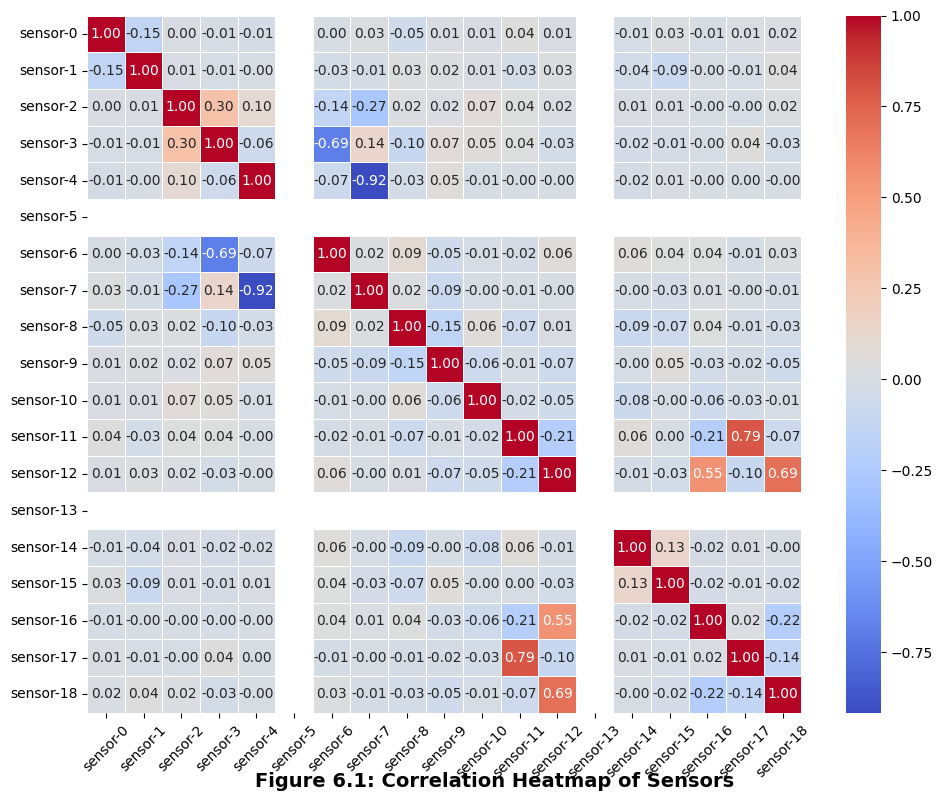

In [14]:
# 2. Calculate Correlation Matrix
corr_matrix = wafers.iloc[:, 1:20].corr()

# 3. Setup the matplotlib figure size
plt.figure(figsize=(10, 8))

# 4. Draw the Heatmap
# annot=True adds the numbers inside the boxes
# cmap='coolwarm' gives the Red/Blue color scheme
# fmt='.2f' limits the numbers to 2 decimal places
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f', 
            linewidths=0.5, 
            linecolor='white')

# 5. Add Titles and Labels

plt.xticks(rotation=45)
plt.yticks(rotation=0)
# 5. Add Caption BELOW the image
# (x=0.5 centers it, y=0.01 puts it at the very bottom)
plt.figtext(0.5, 0.01, "Figure 6.1: Correlation Heatmap of Sensors", 
            wrap=True, horizontalalignment='center', fontsize=14, fontweight='bold')

# 6. Adjust margins to make space for the text at the bottom
plt.subplots_adjust(bottom=0.15)


# 6. Save the image to your computer
plt.tight_layout()
plt.savefig('Figure_6.1_Correlation_Heatmap.png', dpi=300)
plt.show()

In [15]:
## Train-Test Split
from sklearn.model_selection import train_test_split

wafers, wafers_test = train_test_split(wafers, test_size=.20, random_state=42)

In [16]:
## Wafers' Info

wafers.info()

<class 'pandas.DataFrame'>
Index: 1253 entries, 415 to 1126
Columns: 592 entries, Wafers to Good/bad
dtypes: float64(590), int64(1), str(1)
memory usage: 5.7 MB


In [17]:
## Description of `wafers`

wafers.describe()

,sensor-0,sensor-1,sensor-2,sensor-3,sensor-4,sensor-5,sensor-6,sensor-7,sensor-8,sensor-9,...,sensor-581,sensor-582,sensor-583,sensor-584,sensor-585,sensor-586,sensor-587,sensor-588,sensor-589,Good/bad
count,1248.000000,1250.000000,1239.000000,1239.000000,1239.000000,1239.0,1239.000000,1244.000000,1251.000000,1251.000000,...,493.000000,1252.000000,1252.000000,1252.000000,1252.000000,1252.000000,1252.000000,1252.000000,1252.000000,1253.000000
mean,3015.487356,2496.857464,2200.426111,1391.297314,4.922685,100.0,101.062080,0.121624,1.462113,-0.000674,...,97.636106,0.499976,0.015486,0.003889,3.103586,0.021351,0.016410,0.005249,100.508164,-0.872306
std,74.922126,80.782323,29.702387,439.316275,63.077977,0.0,6.129902,0.009975,0.073954,0.014983,...,87.175510,0.003375,0.019041,0.004133,3.968673,0.012385,0.008636,0.002785,94.544100,0.489155
min,2743.240000,2158.750000,2060.660000,0.000000,0.681500,100.0,82.131100,0.000000,1.191000,-0.053400,...,0.000000,0.477800,0.006000,0.001700,1.197500,-0.016900,0.003200,0.001000,0.000000,-1.000000
25%,2965.645000,2453.532500,2181.188900,1081.875800,1.017700,100.0,97.762200,0.121100,1.411100,-0.010500,...,46.416500,0.497900,0.011600,0.003100,2.320975,0.013300,0.010600,0.003300,44.368600,-1.000000
50%,3011.840000,2500.090000,2200.988900,1283.370100,1.317100,100.0,101.492200,0.122250,1.460300,-0.001000,...,71.778000,0.500000,0.013800,0.003600,2.763500,0.020300,0.014800,0.004600,72.023000,-1.000000
75%,3057.787500,2539.492500,2217.666700,1586.947600,1.527400,100.0,104.621150,0.123800,1.516700,0.008600,...,117.094500,0.502300,0.016600,0.004100,3.322000,0.027700,0.020425,0.006400,116.682600,-1.000000
max,3356.350000,2839.460000,2315.266700,3715.041700,1114.536600,100.0,129.252200,0.128600,1.656400,0.060900,...,737.304800,0.509800,0.476600,0.104500,99.303200,0.102800,0.079900,0.028600,737.304800,1.000000


### Insight:

From the gist of only shown columns, it looks like some of features have pretty bad outliers. One thing is for sure, the data must be standardized.

In [18]:
## Looking at the Cats in our Target feature

wafers["Good/bad"].value_counts()

Good/bad
-1    1173
 1      80
Name: count, dtype: int64

### Insight:

Heavily imbalanced. Definitely gonna need `resampling`.

## # Analyze Missing Data:

Firstly, we'll check the missing data in the target feature and drop those records. **As if we already know a value of target feature then there's no need for a ML algorithm, damn right?** Therefore, the best way to deal with missing target entries is to delete them. For other missing features, we can definitely use impute strategies.

In [19]:
## Check missing vals in target feature

wafers["Good/bad"].isna().sum()

np.int64(0)

**=>** Woa, not even a single missing entry, I didn't see that coming.

In [20]:
## Check missing vals in dependent feature variables

wafers.isna().sum().sum() / (wafers.shape[0] * (wafers.shape[1] - 1))

np.float64(0.045323372805436156)

**=>** Almost 4% out of total cells we're having, are missing.

We're gonna try all sort of imputation strategies and would choose the one with that's gonna give us least overall-error-val.

## # Visualization of Sensors' distribution:

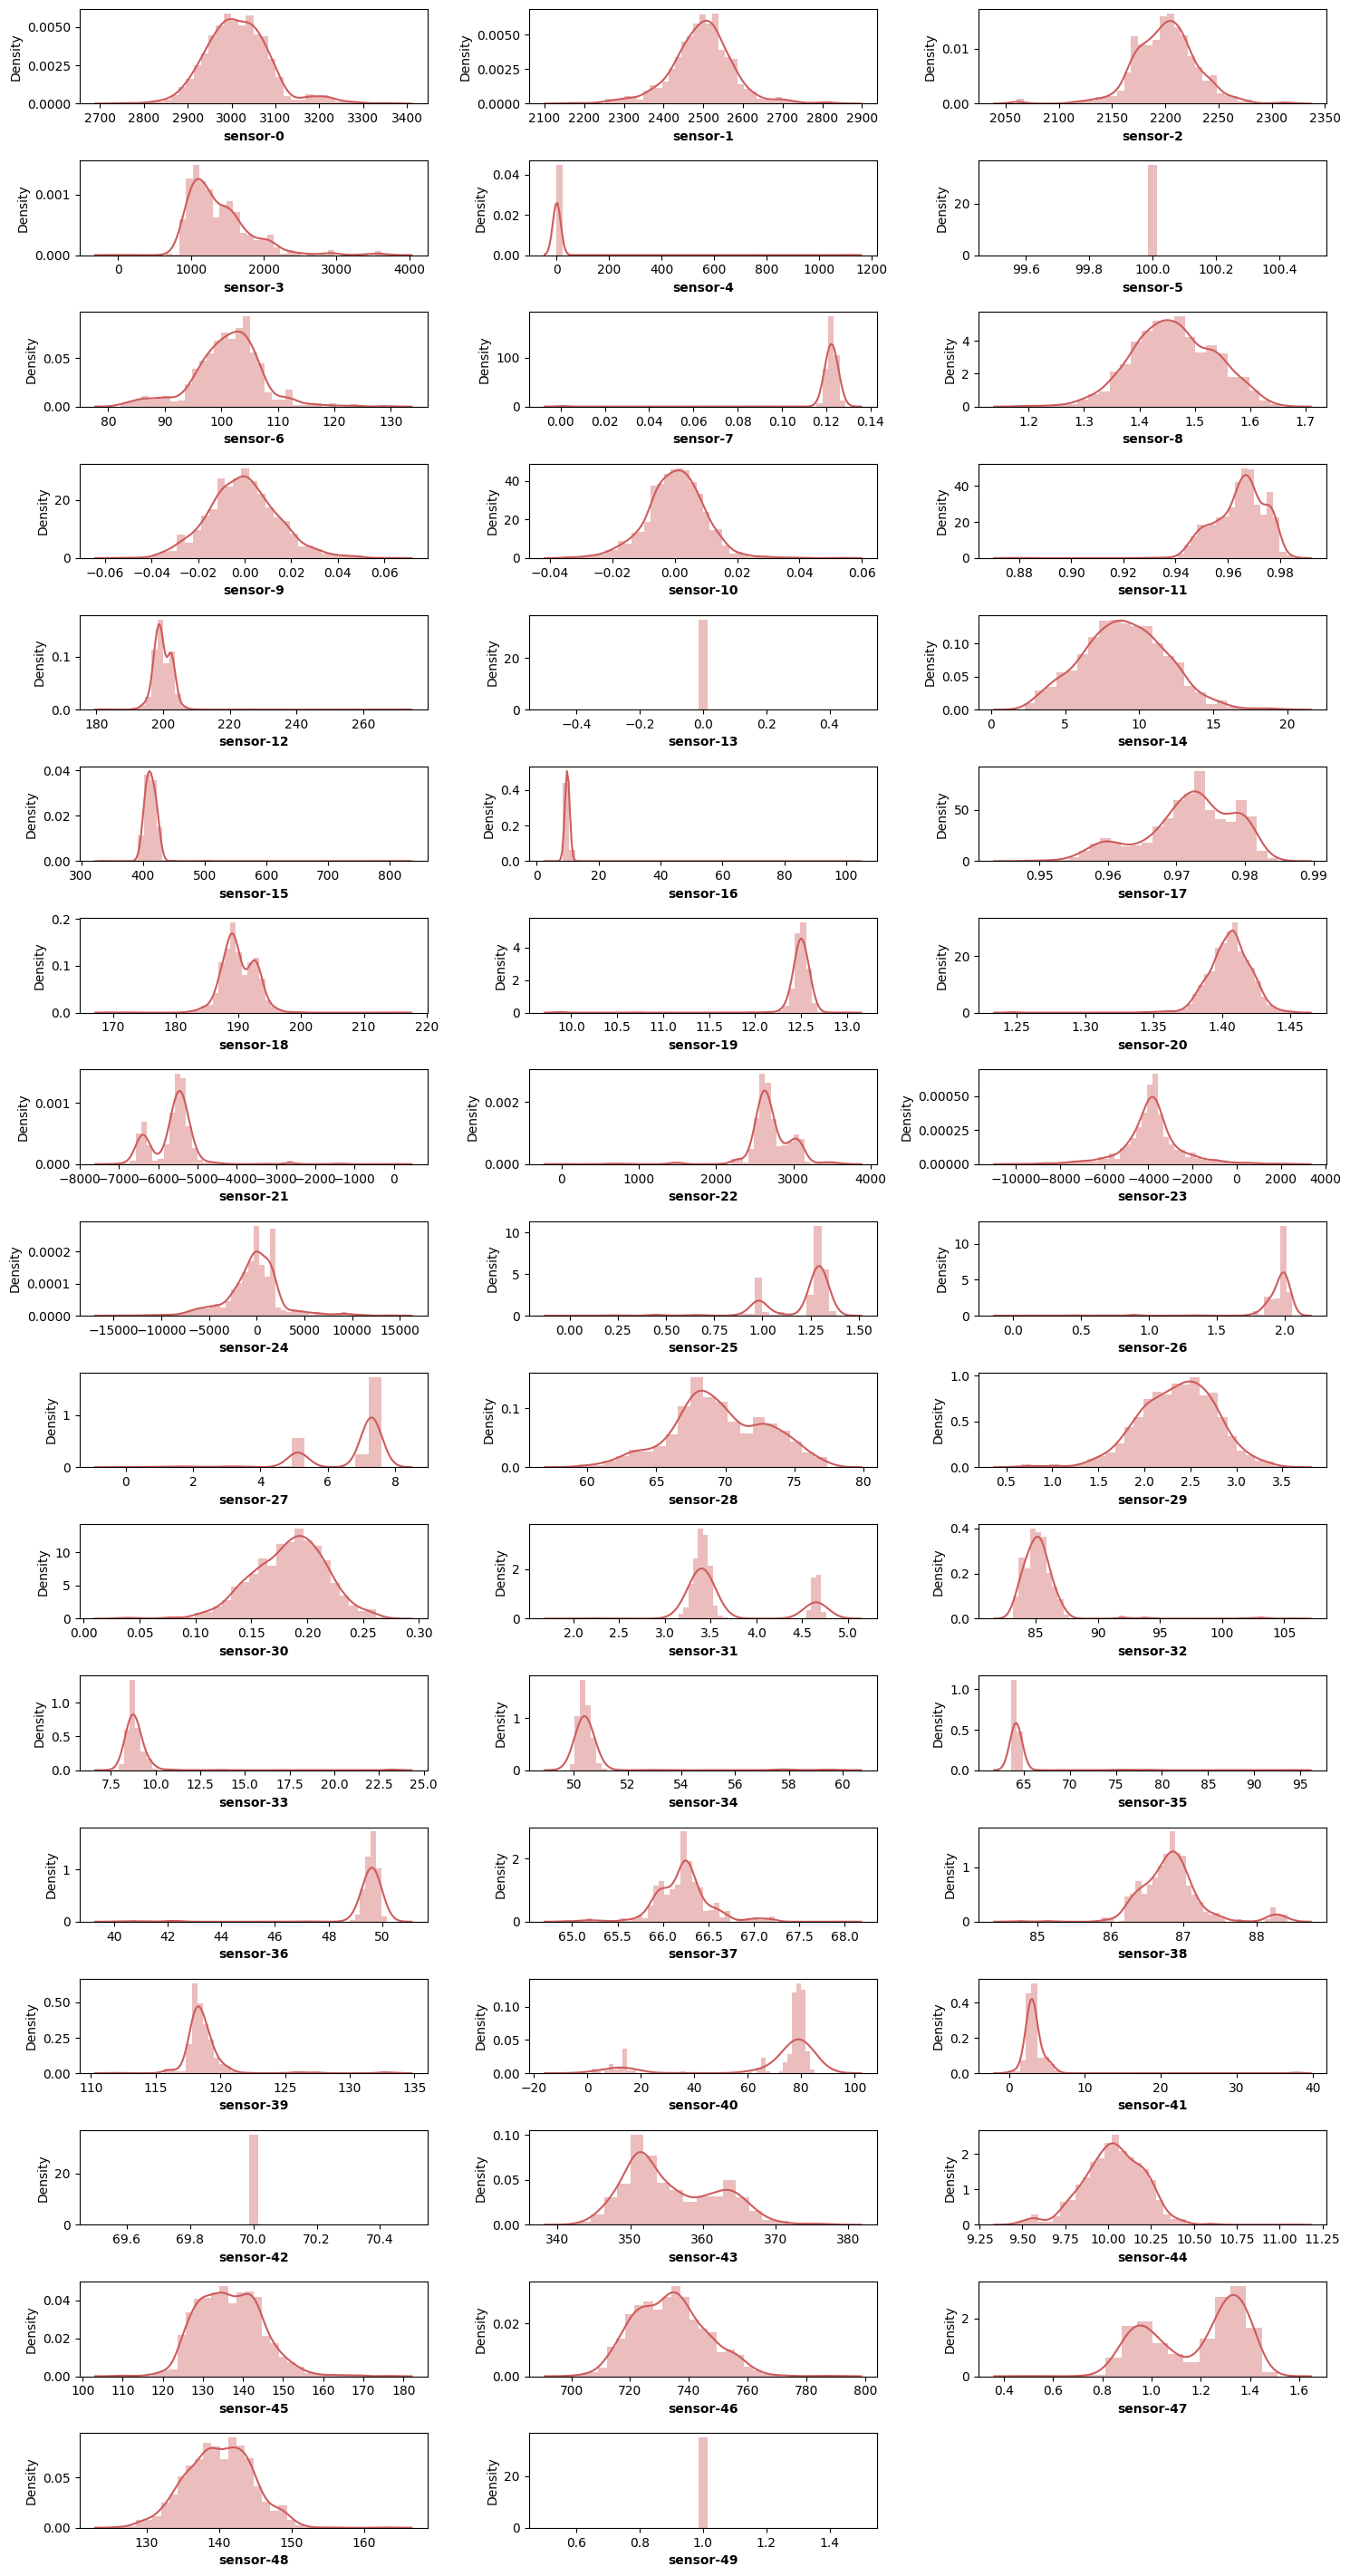

In [21]:
# let's have a look at the distribution first 50 sensors of Wafers

plt.figure(figsize=(15, 100))

for i, col in enumerate(wafers.columns[1:51]):
    plt.subplot(60, 3, i+1)
    sns.distplot(x=wafers[col], color='indianred')
    plt.xlabel(col, weight='bold')
    plt.tight_layout()

In [22]:
# Select 50 random sensors

random_50_sensors_idx = []
for i in range(50):
    if i not in random_50_sensors_idx:
        random_50_sensors_idx.append(np.random.randint(1, 591))

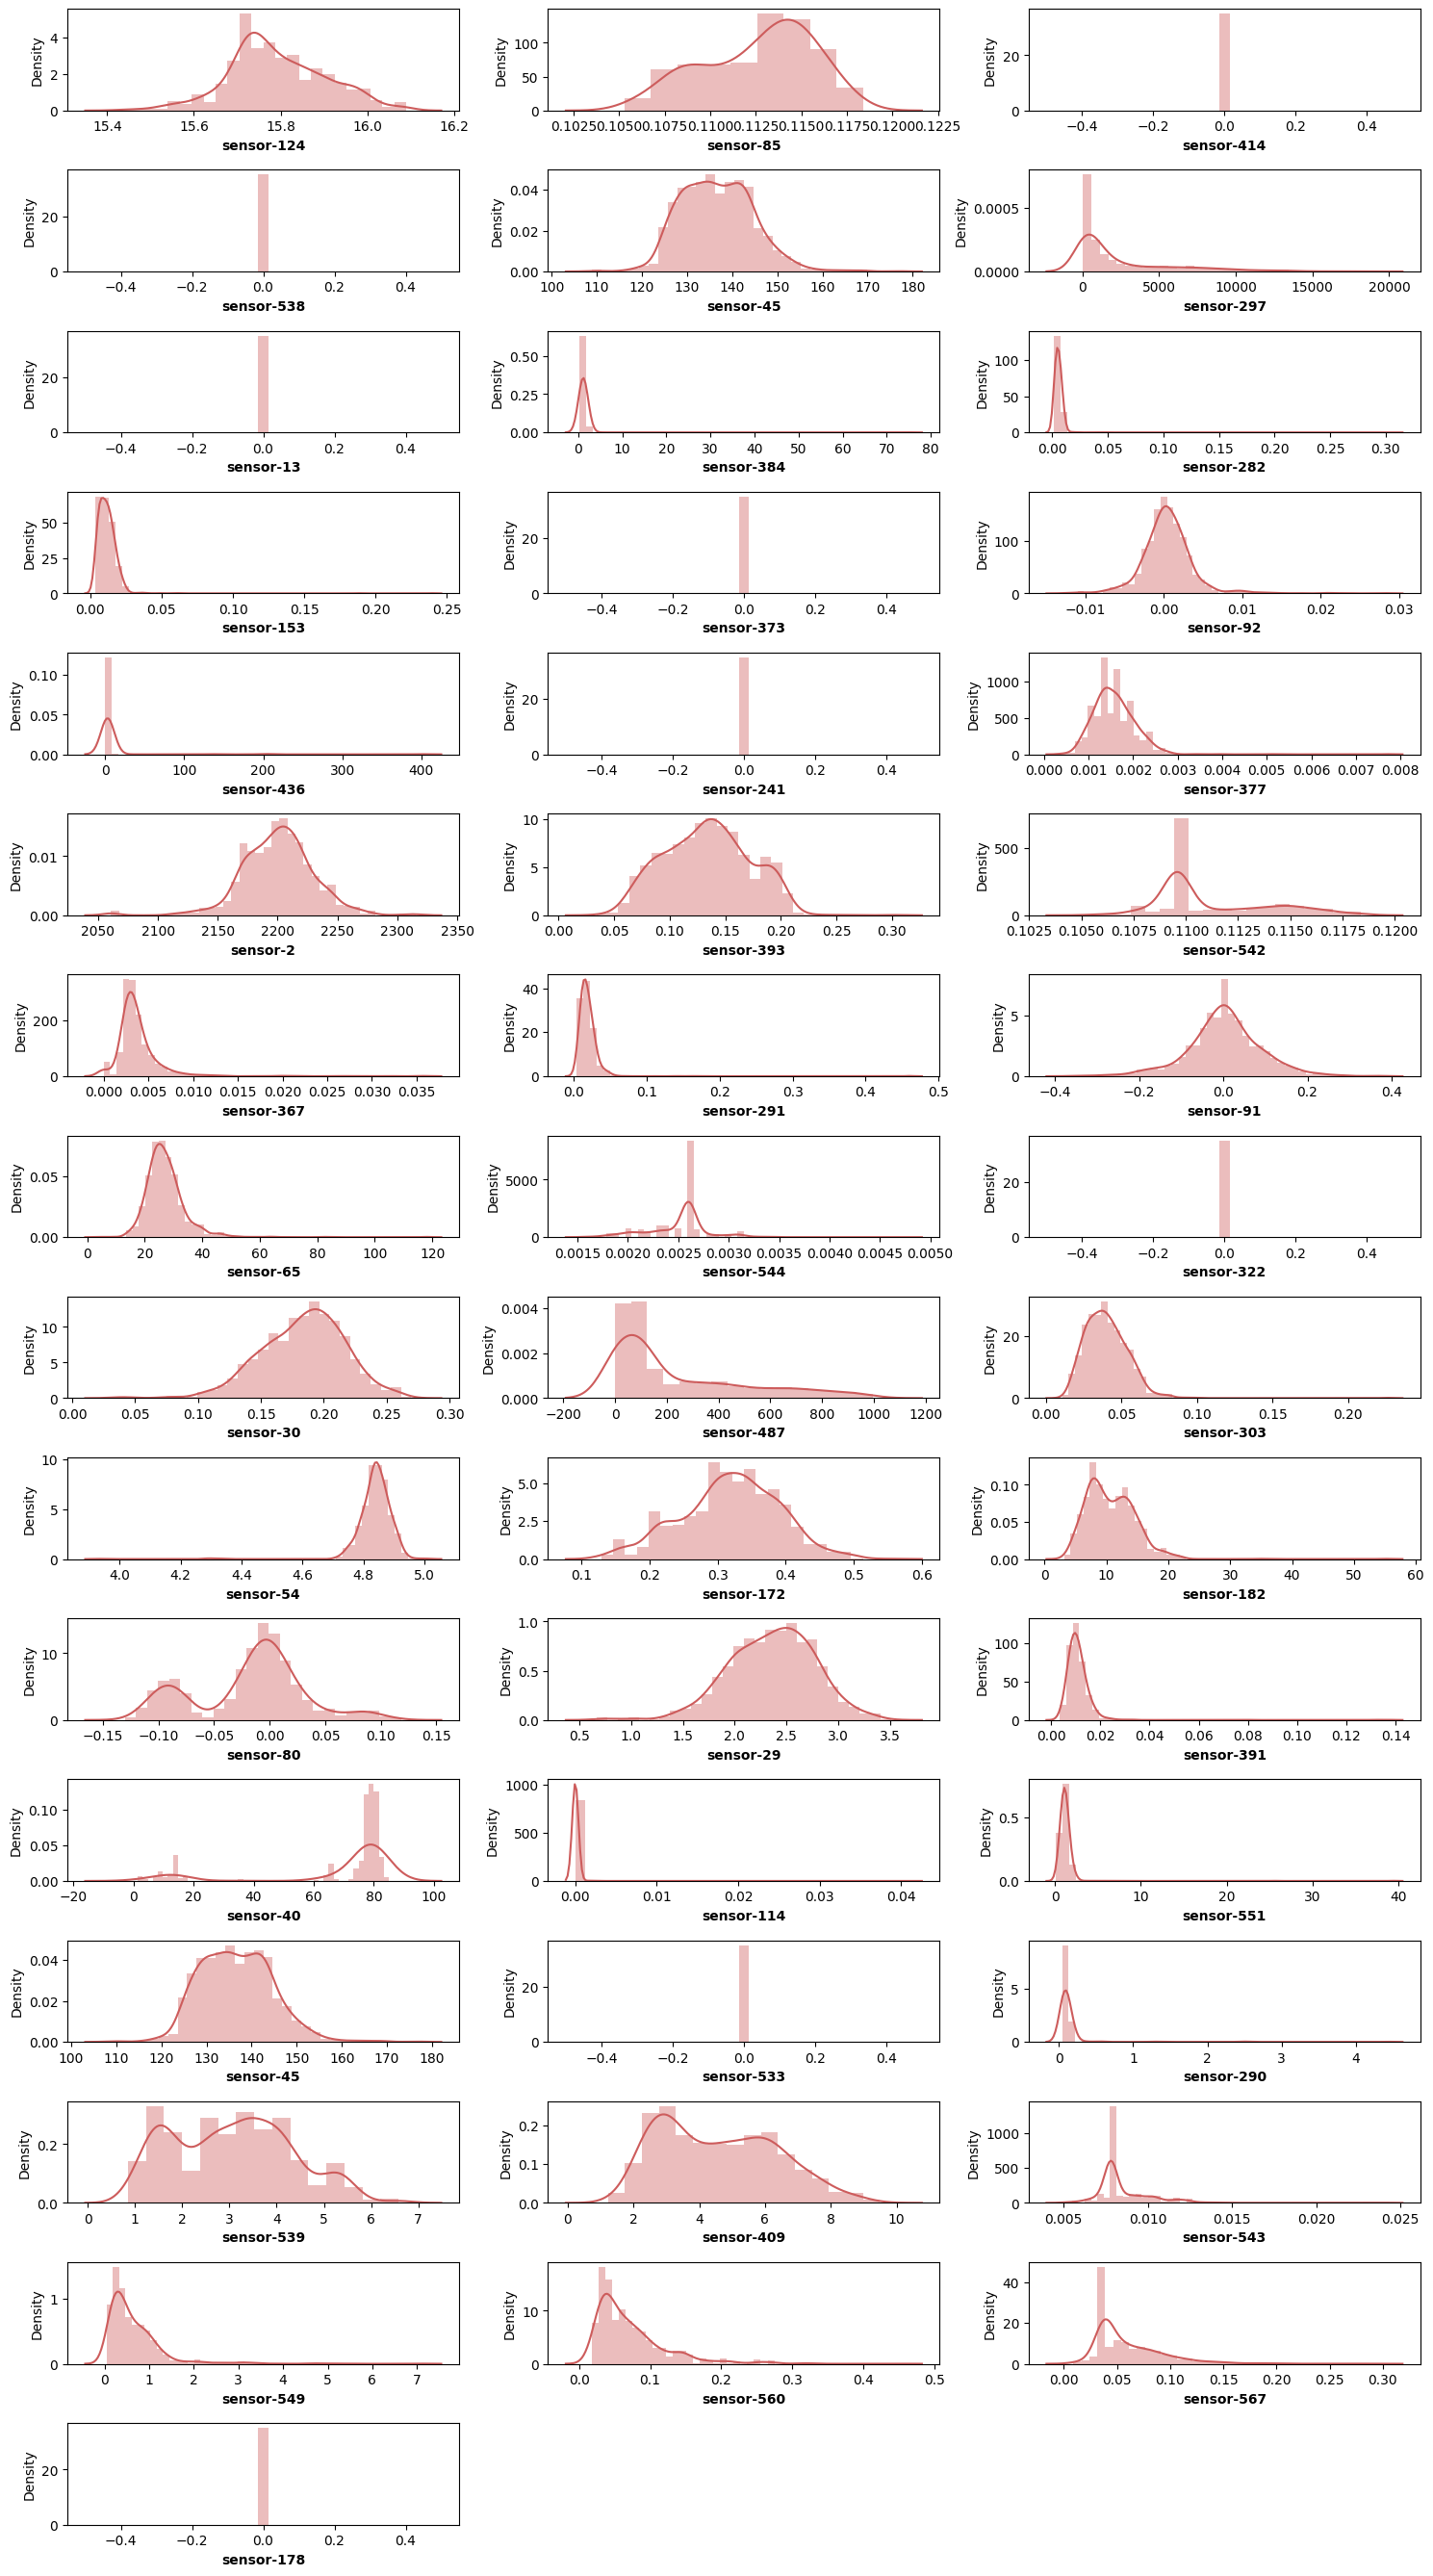

In [23]:
# let's now, have a look at the distribution of random 50 sensors

plt.figure(figsize=(15, 100))

for i, col in enumerate(wafers.columns[random_50_sensors_idx]):
    plt.subplot(60, 3, i+1)
    sns.distplot(x=wafers[col], color='indianred')
    plt.xlabel(col, weight='bold')
    plt.tight_layout()

### Insight:

Pretty good amount of them (either first 50 or random 50) either are constant (have 0 standard deviation) or have left skewness and right skewness. It ain't possible to analyze each feature and deal with its outliers individually, thus we oughta depend upon the scaling. 

For the **features with 0 standard deviation**, we can straight away drop them and for others that do have outliers, we gotta go ahead with the `Robust Scaling`.

### # Get Columns to Drop:

Will drop columns with zero standard deviation as they are not influencing the target variable in any way.

In [24]:
def get_cols_with_zero_std_dev(df: pd.DataFrame):
    """
    Returns a list of columns names who are having zero standard deviation.
    """
    cols_to_drop = []

    # Select only numeric columns safely
    num_df = df.select_dtypes(include=[np.number])

    for col in num_df.columns:
        if num_df[col].std() == 0:
            cols_to_drop.append(col)

    return cols_to_drop
def get_redundant_cols(df: pd.DataFrame, missing_thresh=.7):
    """
    Returns a list of columns having missing values more than certain thresh.
    """
    cols_missing_ratios = df.isna().sum().div(df.shape[0])
    cols_to_drop = list(cols_missing_ratios[cols_missing_ratios > missing_thresh].index)
    return cols_to_drop        

In [25]:
## Columns w missing vals more than 70%

cols_to_drop_1 = get_redundant_cols(wafers, missing_thresh=.7)
cols_to_drop_1

['sensor-85',
 'sensor-157',
 'sensor-158',
 'sensor-220',
 'sensor-292',
 'sensor-293',
 'sensor-358',
 'sensor-492']

In [26]:
## Columns w 0 Standard Deviation

cols_to_drop_2 = get_cols_with_zero_std_dev(wafers)
cols_to_drop_2

['sensor-5',
 'sensor-13',
 'sensor-42',
 'sensor-49',
 'sensor-52',
 'sensor-69',
 'sensor-97',
 'sensor-141',
 'sensor-149',
 'sensor-178',
 'sensor-179',
 'sensor-186',
 'sensor-189',
 'sensor-190',
 'sensor-191',
 'sensor-192',
 'sensor-193',
 'sensor-194',
 'sensor-226',
 'sensor-229',
 'sensor-230',
 'sensor-231',
 'sensor-232',
 'sensor-233',
 'sensor-234',
 'sensor-235',
 'sensor-236',
 'sensor-237',
 'sensor-240',
 'sensor-241',
 'sensor-242',
 'sensor-243',
 'sensor-256',
 'sensor-257',
 'sensor-258',
 'sensor-259',
 'sensor-260',
 'sensor-261',
 'sensor-262',
 'sensor-263',
 'sensor-264',
 'sensor-265',
 'sensor-266',
 'sensor-276',
 'sensor-284',
 'sensor-313',
 'sensor-314',
 'sensor-315',
 'sensor-322',
 'sensor-325',
 'sensor-326',
 'sensor-327',
 'sensor-328',
 'sensor-329',
 'sensor-330',
 'sensor-364',
 'sensor-369',
 'sensor-370',
 'sensor-371',
 'sensor-372',
 'sensor-373',
 'sensor-374',
 'sensor-375',
 'sensor-378',
 'sensor-379',
 'sensor-380',
 'sensor-381',
 's

In [27]:
## Cols to drop

cols_to_drop = cols_to_drop_1 + cols_to_drop_2

**=>** Features that are not gonna contribute to ML algorithm in anyway, whatsoever.

## # Separate Features and Labels out:

In [28]:
## Separate features and Labels out

X, y = wafers.drop(cols_to_drop, axis=1), wafers[["Good/bad"]]

In [29]:
## Dependent feature variables

print("Shape of the features now: ", X.shape)
X.head()
X = X.iloc[:, 1:]

Shape of the features now:  (1253, 468)


**=>** Now, we have 475 contributing features.

In [30]:
## Independent/Target Variables

print("Shape of the labels: ", y.shape)
y.head()

Shape of the labels:  (1253, 1)


,Good/bad
415,-1
879,-1
413,-1
58,1
354,-1


## # Data Transformation:

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
# from sklearn.preprocessing import StandardScaler

imputer = KNNImputer(n_neighbors=3)
preprocessing_pipeline = Pipeline(
    steps=[('Imputer', imputer), ('Scaler', RobustScaler())])
preprocessing_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Imputer', ...), ('Scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan or None, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`should be set to np.nan, since `pd.NA` will be converted to np.nan.",nan
,"n_neighbors n_neighbors: int, default=5Number of neighboring samples to use for imputation.",3
,"weights weights: {'uniform', 'distance'} or callable, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- callable : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.",'uniform'
,"metric metric: {'nan_euclidean'} or callable, default='nan_euclidean'Distance metric for searching neighbors. Possible values:- 'nan_euclidean'- callable : a user-defined function which conforms to the definition of ``func_metric(x, y, *, missing_values=np.nan)``. `x` and `y` corresponds to a row (i.e. 1-D arrays) of `X` and `Y`, respectively. The callable should returns a scalar distance value.",'nan_euclidean'
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto theoutput of the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear on themissing indicator even if there are missing values at transform/testtime.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0`... versionadded:: 1.2",False


In [32]:
## Transform "Wafers" features

X_trans = preprocessing_pipeline.fit_transform(X)
print("Shape of transformed features set: ", X_trans.shape)
X_trans

Shape of transformed features set:  (1253, 467)


array([[-0.65183899,  0.89770744,  0.19056425, ...,  0.12903226,
         1.52857953,  0.        ],
       [-0.13670392,  0.37856395, -0.32495251, ..., -0.58064516,
        -0.09661338,  0.        ],
       [ 0.78116524,  0.42243687,  0.35661173, ...,  0.90322581,
         1.03009237,  0.        ],
       ...,
       [ 0.75783878, -0.53939253, -0.71632402, ..., -0.03225806,
        -0.0940952 ,  0.        ],
       [-0.05088424,  0.42755731, -0.24725978, ...,  0.48387097,
         6.5500567 ,  0.        ],
       [ 0.29564934, -0.78319562,  0.58721229, ..., -0.35483871,
        -0.36828553,  0.        ]], shape=(1253, 467))

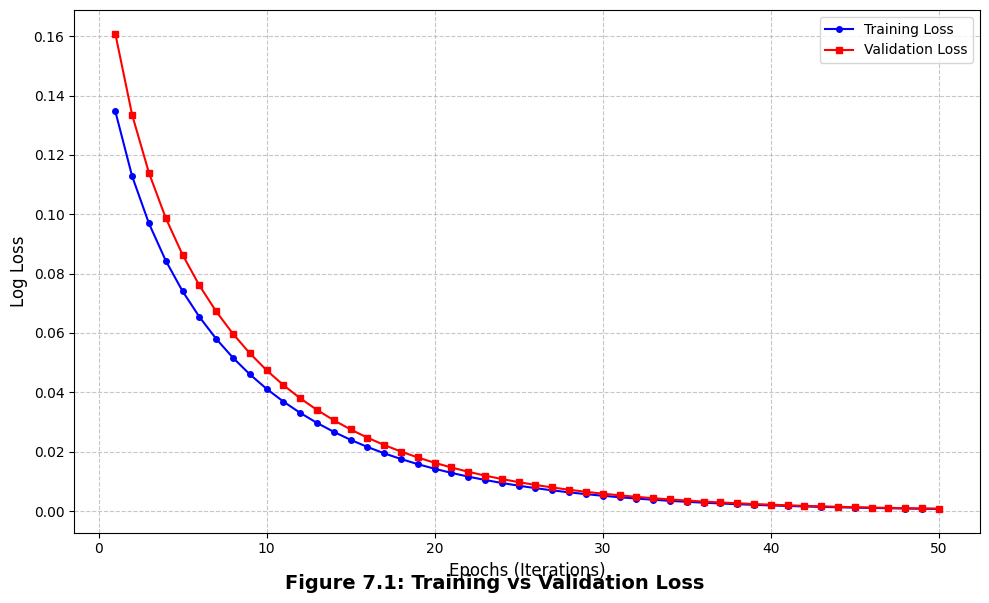

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import log_loss

# 1. Prepare Data
# Ensure X_trans (features) and y (target) are available from previous cells
X_train_plot, X_val_plot, y_train_plot, y_val_plot = train_test_split(
    X_trans, y, test_size=0.2, random_state=42
)

# 2. Train an Iterative Model (Gradient Boosting)
# We use Gradient Boosting because it builds trees sequentially (epochs)
gb_clf = GradientBoostingClassifier(
    n_estimators=50,   # Number of "epochs"
    learning_rate=0.1, 
    max_depth=3, 
    random_state=42
)

gb_clf.fit(X_train_plot, y_train_plot)

# 3. Calculate Loss at Each Iteration
train_loss = []
val_loss = []

# staged_predict_proba allows us to see the model's prediction after each tree is added
for y_pred in gb_clf.staged_predict_proba(X_train_plot):
    train_loss.append(log_loss(y_train_plot, y_pred))

for y_pred in gb_clf.staged_predict_proba(X_val_plot):
    val_loss.append(log_loss(y_val_plot, y_pred))

# 4. Generate the Plot
plt.figure(figsize=(10, 6))
epochs = np.arange(1, len(train_loss) + 1)
plt.plot(epochs, train_loss, 'b-o', label='Training Loss', markersize=4)
plt.plot(epochs, val_loss, 'r-s', label='Validation Loss', markersize=4)


plt.xlabel('Epochs (Iterations)', fontsize=12)
plt.ylabel('Log Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.figtext(0.5, 0.01, 'Figure 7.1: Training vs Validation Loss', 
            wrap=True, horizontalalignment='center', fontsize=14, fontweight='bold')

# 6. Adjust margins to make space for the text at the bottom
plt.subplots_adjust(bottom=0.15)

# 5. Save and Show
plt.tight_layout()
plt.savefig('Figure_7.1_Training_Validation_Loss.png', dpi=300)
plt.show()

## # Shall we cluster "Wafers" instances?

Let's see whether clustering of data instances do us any good. 

In [34]:
%pip install kneed

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
from typing import Tuple
from dataclasses import dataclass


@dataclass
class ClusterDataInstances:
    """Divides the given data instances into different clusters via KMeans Clustering algorithm.

    Args:
        X (np.array): Takes in an array which gotta be clustered.
        desc (str): Description of the said array.
    """
    X: np.array
    desc: str

    def _get_ideal_number_of_clusters(self):
        """Returns the ideal number of clusters the given data instances should be divided into by 
        locating the dispersal point in number of clusters vs WCSS plot.

        Raises:
            e: Raises relevant exception should any kinda error pops up while determining the ideal
            number of clusters.

        Returns:
            int: Ideal number of clusters the given data instances should be divided into.
        """
        try:
            print(
                f'Getting the ideal number of clusters to cluster "{self.desc} set" into..')

            ####################### Compute WCSS for shortlisted number of clusters ##########################
            print("computing WCSS for shortlisted number of clusters..")
            wcss = []  # Within Summation of Squares
            for i in range(1, 11):
                kmeans = KMeans(n_clusters=i, init='k-means++',
                                random_state=42)
                kmeans.fit(self.X)
                wcss.append(kmeans.inertia_)
                print(f"WCSS for n_clusters={i}: {kmeans.inertia_}")
            print(
                "WCSS computed successfully for all shortlisted number of clusters!")

            ################### Finalize dispersal point as the ideal number of clusters #####################
            print(
                "Finding the ideal number of clusters (by locating the dispersal point) via Elbow method..")
            knee_finder = KneeLocator(
                range(1, 11), wcss, curve='convex', direction='decreasing')  # range(1, 11) vs WCSS
            print(
                f"Ideal number of clusters to be formed: {knee_finder.knee}")

            return knee_finder.knee
            ...
        except Exception as e:
            print(e)
            raise e

    def create_clusters(self) -> Tuple:
        """Divides the given data instances into the different clusters, they first hand shoud've been divided into
        via offcourse Kmeans Clustering algorithm.

        Raises:
            e: Raises relevant exception should any kinda error pops up while dividing the given data instances into
            clusters.

        Returns:
            (KMeans, np.array): KMeans Clustering object being used to cluster the given data instances and the given dataset 
            along with the cluster labels, respectively.
        """
        try:
            ideal_clusters = self._get_ideal_number_of_clusters()
            print(
                f"Dividing the \"{self.desc}\" instances into {ideal_clusters} clusters via KMeans Clustering algorithm..")
            kmeans = KMeans(n_clusters=ideal_clusters,
                            init='k-means++', random_state=42)
            y_kmeans = kmeans.fit_predict(self.X)
            print(
                f"..said data instances divided into {ideal_clusters} clusters successfully!")

            return kmeans, np.c_[self.X, y_kmeans]
            ...
        except Exception as e:
            print(e)
            raise e

In [36]:
## Cluster `Wafer` instances

cluster_wafers = ClusterDataInstances(X=X_trans, desc="wafers features")
clusterer, X_clus = cluster_wafers.create_clusters()
X_clus

Getting the ideal number of clusters to cluster "wafers features set" into..
computing WCSS for shortlisted number of clusters..
WCSS for n_clusters=1: 129226741837.73013
WCSS for n_clusters=2: 12584625257.287487
WCSS for n_clusters=3: 9115962322.05624
WCSS for n_clusters=4: 420319453.960948
WCSS for n_clusters=5: 157635749.17697996
WCSS for n_clusters=6: 66531449.14041424
WCSS for n_clusters=7: 44486201.42202732
WCSS for n_clusters=8: 31209784.869689062
WCSS for n_clusters=9: 19981680.45518492
WCSS for n_clusters=10: 10202112.192410452
WCSS computed successfully for all shortlisted number of clusters!
Finding the ideal number of clusters (by locating the dispersal point) via Elbow method..
Ideal number of clusters to be formed: 2
Dividing the "wafers features" instances into 2 clusters via KMeans Clustering algorithm..
..said data instances divided into 2 clusters successfully!


array([[-0.65183899,  0.89770744,  0.19056425, ...,  1.52857953,
         0.        ,  0.        ],
       [-0.13670392,  0.37856395, -0.32495251, ..., -0.09661338,
         0.        ,  0.        ],
       [ 0.78116524,  0.42243687,  0.35661173, ...,  1.03009237,
         0.        ,  0.        ],
       ...,
       [ 0.75783878, -0.53939253, -0.71632402, ..., -0.0940952 ,
         0.        ,  0.        ],
       [-0.05088424,  0.42755731, -0.24725978, ...,  6.5500567 ,
         0.        ,  0.        ],
       [ 0.29564934, -0.78319562,  0.58721229, ..., -0.36828553,
         0.        ,  0.        ]], shape=(1253, 468))

In [37]:
## Clusters

np.unique(X_clus[:, -1])

array([0., 1.])

**=>** So the dataset was divided into 3 optimal clusters.

Let's have a look at their shapes..

In [38]:
## Configure "Clustered" array along with target features
wafers_clus = np.c_[X_clus, y]

## Cluster_1 data
wafers_1 = wafers_clus[wafers_clus[:, -2] == 0]
wafers_1.shape

(1249, 469)

**=>** Perhaps we were wrong about dividing the `Wafers` dataset into clusters, as we can see pretty much of all datapoints lie in the first cluster itself.

Let's take look at another clusters anyway..

In [39]:
## Cluster_2 data

wafers_clus[wafers_clus[:, -2] == 1].shape

(4, 469)

**=>** Man, seriously?!

In [40]:
## Cluster_3 data

wafers_clus[wafers_clus[:, -2] == 2].shape

(0, 469)

**=>** Thus we mustn't divide the dataset into clusters. Not a good idea!

## # Resampling of Training Instances:

Resampling is imperative in this case as the target variable is highly imbalanced.

In [41]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
from imblearn.combine import SMOTETomek

X, y = X_trans[:, :-1], y
resampler = SMOTETomek(sampling_strategy="auto")
X_res, y_res = resampler.fit_resample(X, y)

In [43]:
print("Before resampling, Shape of training instances: ", np.c_[X, y].shape)
print("After resampling, Shape of training instances: ", np.c_[X_res, y_res].shape)

Before resampling, Shape of training instances:  (1253, 467)
After resampling, Shape of training instances:  (2338, 467)


In [44]:
## Target Cats after Resampling

print(np.unique(y_res))
print(f"Value Counts: \n-1: {len(y_res[y_res == -1])}, 1: {len(y_res[y_res == 1])}")

[-1  1]
Value Counts: 
-1: 2338, 1: 2338


**=>** Exactly what we wanted!

### # Prepare the Test set:

Do exactly the same to test set whatever's been done to the test set.

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=1/3, random_state=42)

print(f"train set: {X_train.shape, y_train.shape}")
print(f"test set: {X_test.shape, y_test.shape}")

train set: ((1558, 466), (1558, 1))
test set: ((780, 466), (780, 1))


In [46]:
# # fetch only features that were used in training
# X_test, y_test = wafers_test[preprocessing_pipeline.feature_names_in_], wafers_test.iloc[:, -1]

# ## Transform the Test features
# X_test_trans = preprocessing_pipeline.transform(X_test)
# print(X_test_trans.shape, y_test.shape)

# ## Cluster the test features
# y_test_kmeans = clusterer.predict(X_test_trans)

# ## Configure the test array
# test_arr = np.c_[X_test_trans, y_test, y_test_kmeans]
# np.unique(y_test_kmeans)

In [47]:
# # Prepare the test features and test labels for cluster one

# X_test_prep, y_test_prep = test_arr[test_arr[:, -2] == ], test_arr[:, -1]
# print(X_test_prep.shape)

## # Model Selection and Training:

In [48]:
# %pip install xgboost==0.90

In [49]:
# # Prepared training sets

# X_prep = wafers_1[:, :-2]
# y_prep = wafers_1[:, -1]
# print(X_prep.shape, y_prep.shape)

In [50]:
# Prepared training and test sets

X_prep = X_train
y_prep = y_train
X_test_prep = X_test
y_test_prep = y_test

print(X_prep.shape, y_prep.shape)
print(X_test_prep.shape, y_test_prep.shape)

(1558, 466) (1558, 1)
(780, 466) (780, 1)


In [51]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score

# Shortlisted base Models
svc_clf = SVC(kernel='linear')
svc_rbf_clf = SVC(kernel='rbf')
random_clf = RandomForestClassifier(random_state=42)
xgb_clf = XGBClassifier(objective='binary:logistic')

In [52]:
## A function to display Scores

def display_scores(scores):
    print("Scores: ", scores)
    print("Mean: ", scores.mean())
    print("Standard Deviation: ", scores.std())

### # Evaluating `SVC (kernel='linear')` using cross-validation:

In [53]:
## SVC Scores

svc_scores = cross_val_score(svc_clf, X_prep, y_prep, scoring='roc_auc', cv=10, verbose=2)

[CV] END .................................................... total time=   8.3s
[CV] END .................................................... total time=  27.0s
[CV] END .................................................... total time=   5.5s
[CV] END .................................................... total time=   7.2s
[CV] END .................................................... total time=  17.2s
[CV] END .................................................... total time=   3.5s
[CV] END .................................................... total time=   2.0s
[CV] END .................................................... total time=  10.2s
[CV] END .................................................... total time=  25.2s
[CV] END .................................................... total time=  15.5s


[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:  2.0min finished


In [54]:
display_scores(svc_scores)

Scores:  [0.95331251 0.92092717 0.95051784 0.92963998 0.94838073 0.98701299
 0.98865691 0.95298373 0.96353646 0.93306693]
Mean:  0.9528035255883356
Standard Deviation:  0.021303075554044343


In [55]:
## Performance on test set using cross-validation

# Predictions using cross-validation
svc_preds = cross_val_predict(svc_clf, X_test_prep, y_test_prep, cv=5)

# AUC score
svc_auc = roc_auc_score(y_test_prep, svc_preds)
svc_auc

0.9146093580407713

### # Evaluating `SVC (kernel='rbf')` using cross-validation:

In [56]:
## SVC rbf Scores

svc_rbf_scores = cross_val_score(svc_rbf_clf, X_prep, y_prep, scoring='roc_auc', cv=10, verbose=2)

[CV] END .................................................... total time=   0.5s
[CV] END .................................................... total time=   1.0s
[CV] END .................................................... total time=   0.9s
[CV] END .................................................... total time=   0.8s
[CV] END .................................................... total time=   0.7s
[CV] END .................................................... total time=   0.6s
[CV] END .................................................... total time=   0.5s
[CV] END .................................................... total time=   0.3s
[CV] END .................................................... total time=   0.4s
[CV] END .................................................... total time=   0.5s


[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    7.2s finished


In [57]:
display_scores(svc_rbf_scores)

Scores:  [0.71313497 0.74831498 0.63389775 0.73549236 0.70918954 0.6879829
 0.7057373  0.68650337 0.58957709 0.68048618]
Mean:  0.6890316434620232
Standard Deviation:  0.04466651223609343


In [58]:
## Performance on test set using cross-validation

# Predictions using cross-validation
svc_rbf_preds = cross_val_predict(svc_rbf_clf, X_test_prep, y_test_prep, cv=5)

# AUC score
svc_rbf_auc = roc_auc_score(y_test_prep, svc_rbf_preds)
svc_rbf_auc

0.5000592031259251

### # Evaluating `RandomForestClassifier` using cross-validation:

In [59]:
## Random Forest Scores

random_clf_scores = cross_val_score(random_clf, X_prep, y_prep, scoring='roc_auc', cv=10, verbose=2)

[CV] END .................................................... total time=   1.6s
[CV] END .................................................... total time=   1.6s
[CV] END .................................................... total time=   1.5s
[CV] END .................................................... total time=   1.6s
[CV] END .................................................... total time=   1.6s
[CV] END .................................................... total time=   1.4s
[CV] END .................................................... total time=   1.6s
[CV] END .................................................... total time=   1.5s
[CV] END .................................................... total time=   1.4s
[CV] END .................................................... total time=   1.9s


[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:   16.6s finished


In [60]:
display_scores(random_clf_scores)

Scores:  [0.99917804 0.99399967 1.         1.         1.         1.
 1.         0.99852047 0.99991675 1.        ]
Mean:  0.9991614925159229
Standard Deviation:  0.0017845046732406767


In [61]:
## Performance on test set using cross-validation

# Predictions using cross-validation
random_clf_preds = cross_val_predict(random_clf, X_test_prep, y_test_prep, cv=5)

# AUC score
random_clf_auc = roc_auc_score(y_test_prep, random_clf_preds)
random_clf_auc

0.9588932962327077

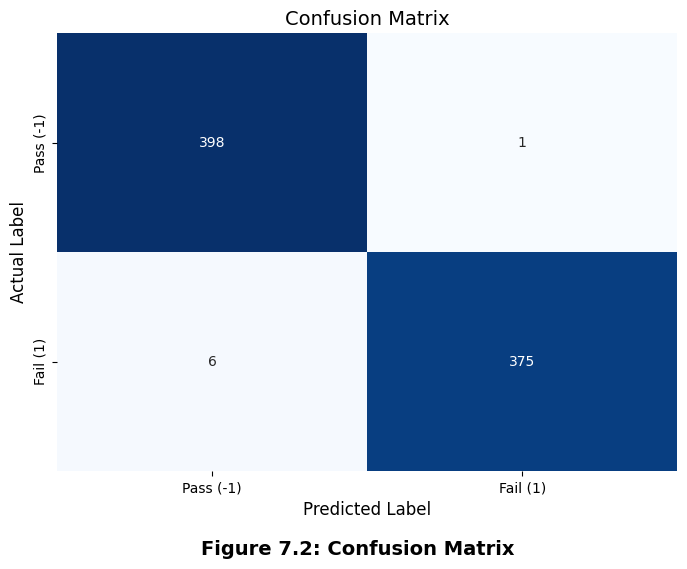

In [65]:
# 1. Fit the model on the Training Data first
# (Assuming X_prep and y_prep are your preprocessed training variables from previous cells)
random_clf.fit(X_prep, y_prep)

# 2. Now Get Predictions on the Test Data
y_pred = random_clf.predict(X_test_prep)

# 3. Calculate the Confusion Matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test_prep, y_pred)

# 4. Setup the Figure
plt.figure(figsize=(8, 6))

# 5. Draw the Heatmap
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues', 
            xticklabels=['Pass (-1)', 'Fail (1)'], 
            yticklabels=['Pass (-1)', 'Fail (1)'],
            cbar=False)

plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.title('Confusion Matrix', fontsize=14)

# 6. Add Caption
plt.figtext(0.5, 0.01, "Figure 7.2: Confusion Matrix", 
            wrap=True, horizontalalignment='center', fontsize=14, fontweight='bold')

plt.subplots_adjust(bottom=0.15)
plt.savefig('Figure_7.2_Confusion_Matrix.png', dpi=300)
plt.show()

In [7]:
import sys
import os
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

# 1. FIX PATHS
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.utils.main_utils import MainUtils

# --- CONFIGURATION ---
DATA_PATH = 'uci-secom.csv'  
MODEL_PATH = '../artifacts/model.pkl'
PREPROCESSOR_PATH = '../artifacts/preprocessor.pkl'

def generate_shap_plots():
    print("1. Loading artifacts...")
    utils = MainUtils()
    
    try:
        model = utils.load_object(MODEL_PATH)
        preprocessor = utils.load_object(PREPROCESSOR_PATH)
    except FileNotFoundError:
        print("ERROR: Could not find model.pkl or preprocessor.pkl.")
        return

    print(f"2. Loading data from {DATA_PATH}...")
    try:
        df = pd.read_csv(DATA_PATH)
    except FileNotFoundError:
        print(f"ERROR: Could not find CSV at {DATA_PATH}")
        return

    # Prepare X (Features)
    if 'Good/Bad' in df.columns:
        X = df.drop(columns=['Good/Bad']) 
    else:
        X = df.iloc[:, :-1] 
        
    if 'Wafers' in X.columns:
        print("   -> Dropping 'Wafers' column (ID)...")
        X = X.drop(columns=['Wafers'])

    print("3. Preprocessing data...")
    try:
        X_transformed = preprocessor.transform(X)
    except ValueError as e:
        print(f"ERROR during transformation: {e}")
        return
    
    feature_names = [f"Sensor_{i}" for i in range(X_transformed.shape[1])]
    X_transformed_df = pd.DataFrame(X_transformed, columns=feature_names)

    print("4. Initializing SHAP Explainer...")
    try:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_transformed_df)
    except Exception as e:
        print(f"SHAP Initialization Error: {e}")
        return

    if isinstance(shap_values, list):
        shap_vals_target = shap_values[1] 
    else:
        shap_vals_target = shap_values

    # --- PLOT 1: SUMMARY PLOT (Caption at Bottom) ---
    print("5. Generating Figure 7.3...")
    plt.figure(figsize=(12, 9)) # Increased height for caption
    
    # Plot SHAP summary
    shap.summary_plot(shap_vals_target, X_transformed_df, show=False)
    
    # Add Bottom Caption
    plt.subplots_adjust(bottom=0.15) # Make space at bottom
    plt.figtext(0.5, 0.02, "Figure 7.3: SHAP Summary Plot", 
                wrap=True, horizontalalignment='center', fontsize=16, fontweight='bold')
    
    plt.savefig('Figure_7.3_SHAP_Summary_Plot.png', dpi=300)
    print("   -> Saved Figure 7.3")

    # --- PLOT 2: WATERFALL PLOT (Caption at Bottom) ---
    print("6. Generating Figure 7.4...")
    
    preds = model.predict(X_transformed)
    unique, counts = np.unique(preds, return_counts=True)
    minority_class = unique[np.argmin(counts)]
    faulty_indices = np.where(preds == minority_class)[0]
    
    if len(faulty_indices) > 0:
        target_idx = faulty_indices[0] 
        print(f"   -> Analyzing Wafer Index: {target_idx}")
        
        base_val = explainer.expected_value
        if isinstance(base_val, list) or isinstance(base_val, np.ndarray):
            base_val = base_val[1] if len(base_val) > 1 else base_val[0]

        explanation = shap.Explanation(
            values=shap_vals_target[target_idx],
            base_values=base_val,
            data=X_transformed_df.iloc[target_idx].values,
            feature_names=feature_names
        )

        plt.figure(figsize=(10, 7)) # Increased height
        
        # Plot Waterfall
        shap.plots.waterfall(explanation, show=False, max_display=10)
        
        # Add Bottom Caption
        plt.subplots_adjust(bottom=0.15)
        plt.figtext(0.5, 0.02, "Figure 7.4: Waterfall Plot", 
                    wrap=True, horizontalalignment='center', fontsize=16, fontweight='bold')
        
        plt.savefig('Figure_7.4_Waterfall_Plot.png', dpi=300)
        print("   -> Saved Figure 7.4")
    else:
        print("   -> No Faulty wafers found.")

    print("\nDONE! Images generated with bottom captions.")

generate_shap_plots()

1. Loading artifacts...
2. Loading data from uci-secom.csv...
   -> Dropping 'Wafers' column (ID)...
3. Preprocessing data...
4. Initializing SHAP Explainer...
5. Generating Figure 7.3...
   -> Saved Figure 7.3
6. Generating Figure 7.4...
   -> Analyzing Wafer Index: 10
   -> Saved Figure 7.4

DONE! Images generated with bottom captions.
